## Extended Data Fig. 7a

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




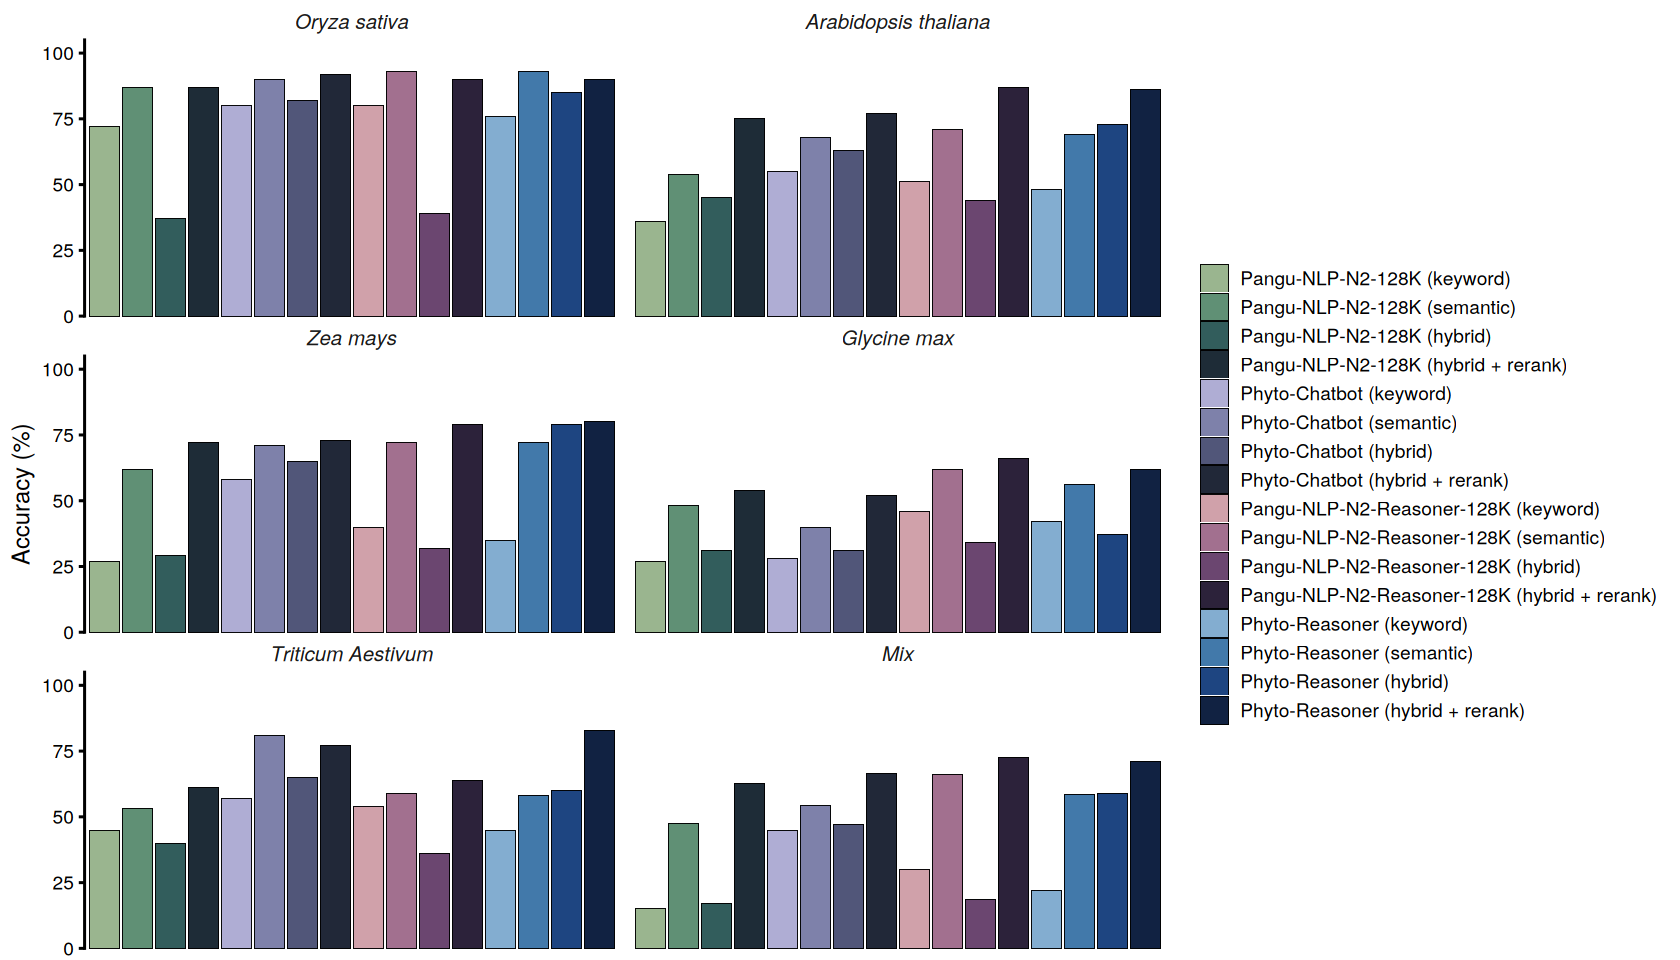

In [1]:
library(tidyverse)
library(ggplot2)
library(scales)

# 1. 内嵌 Figure 5 对应的数据框 (包含正确的消融实验命名规则)
df_fig5 <- tibble(
  model = c(
    "Pangu-NLP-N2-128K (keyword)", "Pangu-NLP-N2-128K (semantic)", "Pangu-NLP-N2-128K (hybrid + rerank)",
    "Phyto-Chatbot (keyword)", "Phyto-Chatbot (semantic)", "Phyto-Chatbot (hybrid + rerank)",
    "Pangu-NLP-N2-Reasoner-128K (keyword)", "Pangu-NLP-N2-Reasoner-128K (semantic)", "Pangu-NLP-N2-Reasoner-128K (hybrid + rerank)",
    "Phyto-Reasoner (keyword)", "Phyto-Reasoner (semantic)", "Phyto-Reasoner (hybrid + rerank)",
    "Phyto-Chatbot (hybrid)", "Phyto-Reasoner (hybrid)",
    "Pangu-NLP-N2-128K (hybrid)", "Pangu-NLP-N2-Reasoner-128K (hybrid)"
  ),
  Arabidopsis.thaliana = c(0.36, 0.54, 0.75, 0.55, 0.68, 0.77, 0.51, 0.71, 0.87, 0.48, 0.69, 0.86, 0.63, 0.73, 0.45, 0.44),
  Oryza.sativa         = c(0.72, 0.87, 0.87, 0.80, 0.90, 0.92, 0.80, 0.93, 0.90, 0.76, 0.93, 0.90, 0.82, 0.85, 0.37, 0.39),
  Zea.mays             = c(0.27, 0.62, 0.72, 0.58, 0.71, 0.73, 0.40, 0.72, 0.79, 0.35, 0.72, 0.80, 0.65, 0.79, 0.29, 0.32),
  Glycine.max          = c(0.27, 0.48, 0.54, 0.28, 0.40, 0.52, 0.46, 0.62, 0.66, 0.42, 0.56, 0.62, 0.31, 0.37, 0.31, 0.34),
  Triticum.Aestivum    = c(0.45, 0.53, 0.61, 0.57, 0.81, 0.77, 0.54, 0.59, 0.64, 0.45, 0.58, 0.83, 0.65, 0.60, 0.40, 0.36),
  Mix                  = c(0.150, 0.475, 0.625, 0.450, 0.545, 0.665, 0.300, 0.660, 0.725, 0.220, 0.585, 0.710, 0.470, 0.590, 0.170, 0.185)
)

# 2. 定义配色矩阵与层级顺序
color_map_fig5 <- c(
  # 第 1 组
  "Pangu-NLP-N2-128K (keyword)"                  = "#9AB58F", 
  "Pangu-NLP-N2-128K (semantic)"                 = "#609075", 
  "Pangu-NLP-N2-128K (hybrid)"                   = "#325D5C", 
  "Pangu-NLP-N2-128K (hybrid + rerank)"          = "#1E2C37", 
  
  # 第 2 组
  "Phyto-Chatbot (keyword)"                      = "#AFADD4", 
  "Phyto-Chatbot (semantic)"                     = "#7E81AA", 
  "Phyto-Chatbot (hybrid)"                       = "#515679", 
  "Phyto-Chatbot (hybrid + rerank)"              = "#212838", 
  
  # 第 3 组
  "Pangu-NLP-N2-Reasoner-128K (keyword)"         = "#D0A1AA", 
  "Pangu-NLP-N2-Reasoner-128K (semantic)"        = "#A2708F", 
  "Pangu-NLP-N2-Reasoner-128K (hybrid)"          = "#6B4670", 
  "Pangu-NLP-N2-Reasoner-128K (hybrid + rerank)" = "#2C223A", 
  
  # 第 4 组
  "Phyto-Reasoner (keyword)"                     = "#83ADD0", 
  "Phyto-Reasoner (semantic)"                    = "#4279AA", 
  "Phyto-Reasoner (hybrid)"                      = "#1E4581", 
  "Phyto-Reasoner (hybrid + rerank)"             = "#112242"  
)

order_fig5 <- c(
  "Pangu-NLP-N2-128K (keyword)", "Pangu-NLP-N2-128K (semantic)", "Pangu-NLP-N2-128K (hybrid)", "Pangu-NLP-N2-128K (hybrid + rerank)",
  "Phyto-Chatbot (keyword)", "Phyto-Chatbot (semantic)", "Phyto-Chatbot (hybrid)", "Phyto-Chatbot (hybrid + rerank)",
  "Pangu-NLP-N2-Reasoner-128K (keyword)", "Pangu-NLP-N2-Reasoner-128K (semantic)", "Pangu-NLP-N2-Reasoner-128K (hybrid)", "Pangu-NLP-N2-Reasoner-128K (hybrid + rerank)",
  "Phyto-Reasoner (keyword)", "Phyto-Reasoner (semantic)", "Phyto-Reasoner (hybrid)", "Phyto-Reasoner (hybrid + rerank)"
)

sp_order <- c("Oryza sativa", "Arabidopsis thaliana", "Zea mays",
              "Glycine max", "Triticum Aestivum", "Mix")

# 3. 数据转换：宽表转长表
df_long_fig5 <- df_fig5 %>%
  pivot_longer(
    cols = -model,
    names_to = "type",
    values_to = "TRUE_Ratio"
  ) %>%
  mutate(type = str_replace(type, "\\.", " ")) %>%
  mutate(
    model = factor(model, levels = intersect(order_fig5, unique(model))),
    type  = factor(type, levels = sp_order)
  )

# 4. 执行绘图
options(repr.plot.width = 14, repr.plot.height = 8)

p5 <- ggplot(df_long_fig5, aes(x = model, y = TRUE_Ratio, fill = model)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.2) +
  facet_wrap(~type, scales = "free_x", ncol = 2) +
  labs(x = NULL, y = "Accuracy (%)") +
  theme_classic(base_size = 14) +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)),
                     breaks = seq(0, 1, 0.25), 
                     labels = seq(0, 100, 25)) +
  theme(
    axis.text.x = element_blank(),  
    axis.ticks.x = element_blank(), 
    axis.line.x = element_blank(),  
    panel.background = element_rect(fill = "white", color = NA),
    plot.background  = element_rect(fill = "white", color = NA),
    strip.text = element_text(size = 12, face = "italic", margin = margin(b = 5)), 
    strip.background = element_blank(), 
    legend.position = "right",      
    legend.title = element_blank()  
  ) +
  scale_fill_manual(values = color_map_fig5)

# 直接打印显示
p5

## Extended Data Fig. 7b

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Ignoring unknown labels:
• size : "12"
Warning message:
“No shared levels found between `names(values)` of the manual scale an

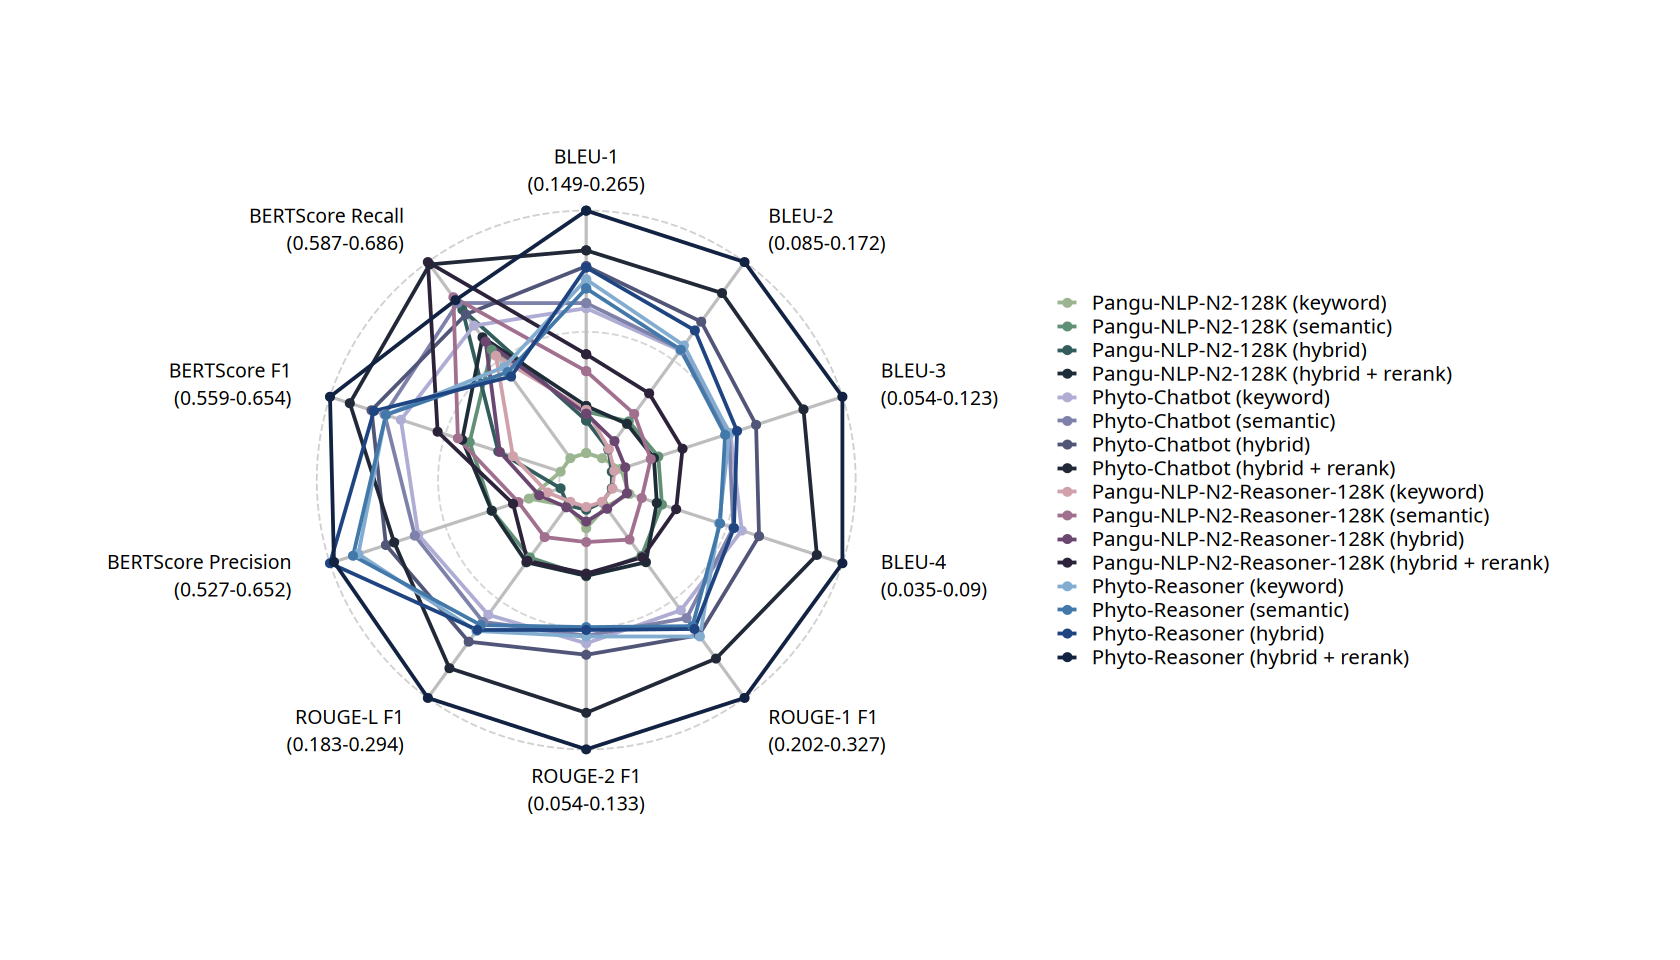

In [1]:
library(tidyverse)
library(ggradar)
library(scales)

# 1. 内嵌 Figure 5 对应的数据框 (包含完整 16 组消融实验指标)
df_fig5 <- tibble(
  model_name = c(
    "Pangu-NLP-N2-128K (keyword)", "Pangu-NLP-N2-128K (hybrid + rerank)", "Pangu-NLP-N2-128K (semantic)",
    "Phyto-Chatbot (keyword)", "Phyto-Chatbot (hybrid + rerank)", "Phyto-Chatbot (semantic)",
    "Pangu-NLP-N2-Reasoner-128K (keyword)", "Pangu-NLP-N2-Reasoner-128K (hybrid + rerank)", "Pangu-NLP-N2-Reasoner-128K (semantic)",
    "Phyto-Reasoner (keyword)", "Phyto-Reasoner (hybrid + rerank)", "Phyto-Reasoner (semantic)",
    "Phyto-Chatbot (hybrid)", "Phyto-Reasoner (hybrid)", "Pangu-NLP-N2-128K (hybrid)", "Pangu-NLP-N2-Reasoner-128K (hybrid)"
  ),
  `BLEU-1`              = c(0.14877629, 0.17130913, 0.16862449, 0.21815375, 0.24585286, 0.22059312, 0.16945225, 0.19607916, 0.18800687, 0.23193163, 0.26488576, 0.22764161, 0.23828351, 0.23767328, 0.16439774, 0.16760411),
  `BLEU-2`              = c(0.08532688, 0.10050846, 0.10161327, 0.13294015, 0.15834360, 0.13349366, 0.08948554, 0.11399762, 0.10489203, 0.13517474, 0.17205927, 0.13326699, 0.14568783, 0.14183051, 0.08919189, 0.09289628),
  `BLEU-3`              = c(0.05658876, 0.06654365, 0.06786171, 0.08957632, 0.11160696, 0.08915670, 0.05459527, 0.07515884, 0.06558889, 0.08931663, 0.12332443, 0.08799843, 0.09731378, 0.09158321, 0.05385805, 0.05790836),
  `BLEU-4`              = c(0.039343857, 0.045860961, 0.047084604, 0.066126810, 0.084018993, 0.064095254, 0.035330070, 0.050471298, 0.042262172, 0.060691016, 0.090108939, 0.060944048, 0.070236007, 0.064243754, 0.035133549, 0.038753143),
  `ROUGE-1 F1`          = c(0.2054164, 0.2405319, 0.2366162, 0.2709884, 0.3016211, 0.2759960, 0.2022403, 0.2373934, 0.2261960, 0.2876344, 0.3265624, 0.2810545, 0.2867912, 0.2828527, 0.2024641, 0.2066832),
  `ROUGE-2 F1`          = c(0.06130531, 0.07666955, 0.07682380, 0.09849707, 0.12092842, 0.09601748, 0.05442030, 0.07595210, 0.06576791, 0.09626645, 0.13274300, 0.09324372, 0.10218136, 0.09416890, 0.05534181, 0.05914924),
  `ROUGE-L F1`          = c(0.1854564, 0.2175601, 0.2148175, 0.2473210, 0.2775920, 0.2513361, 0.1832734, 0.2167076, 0.2032943, 0.2565270, 0.2944282, 0.2531521, 0.2625635, 0.2558936, 0.1853135, 0.1864124),
  `BERTScore Precision` = c(0.5443310, 0.5645180, 0.5643066, 0.6043436, 0.6174101, 0.6061674, 0.5341358, 0.5529179, 0.5500487, 0.6368312, 0.6500484, 0.6397014, 0.6218556, 0.6521874, 0.5271375, 0.5387317),
  `BERTScore F1`        = c(0.5585871, 0.5991300, 0.5960509, 0.6243858, 0.6454374, 0.6310960, 0.5782156, 0.6092521, 0.6009132, 0.6306306, 0.6535978, 0.6305710, 0.6364947, 0.6355017, 0.5842401, 0.5836245),
  `BERTScore Recall`    = c(0.5870792, 0.6477491, 0.6414758, 0.6536405, 0.6843009, 0.6649487, 0.6385015, 0.6855051, 0.6678673, 0.6328417, 0.6664104, 0.6303170, 0.6592442, 0.6280426, 0.6616719, 0.6455956)
)

# 2. 定义排序与严格绑定的 16 色字典
order_fig5 <- c(
  "Pangu-NLP-N2-128K (keyword)", "Pangu-NLP-N2-128K (semantic)", "Pangu-NLP-N2-128K (hybrid)", "Pangu-NLP-N2-128K (hybrid + rerank)",
  "Phyto-Chatbot (keyword)", "Phyto-Chatbot (semantic)", "Phyto-Chatbot (hybrid)", "Phyto-Chatbot (hybrid + rerank)",
  "Pangu-NLP-N2-Reasoner-128K (keyword)", "Pangu-NLP-N2-Reasoner-128K (semantic)", "Pangu-NLP-N2-Reasoner-128K (hybrid)", "Pangu-NLP-N2-Reasoner-128K (hybrid + rerank)",
  "Phyto-Reasoner (keyword)", "Phyto-Reasoner (semantic)", "Phyto-Reasoner (hybrid)", "Phyto-Reasoner (hybrid + rerank)"
)

color_map_fig5 <- setNames(
  c(
    "#9AB58F", "#609075", "#325D5C", "#1E2C37",  # 第 1 组 (绿)
    "#AFADD4", "#7E81AA", "#515679", "#212838",  # 第 2 组 (紫)
    "#D0A1AA", "#A2708F", "#6B4670", "#2C223A",  # 第 3 组 (粉/暗红)
    "#83ADD0", "#4279AA", "#1E4581", "#112242"   # 第 4 组 (蓝)
  ), 
  order_fig5
)

# 3. 准备雷达图数据与极值计算
plot_data <- df_fig5 %>% rename(group = model_name)

range_labels <- plot_data %>%
  select(-group) %>%
  summarise(across(everything(), list(min = ~min(.), max = ~max(.)))) %>%
  pivot_longer(everything(), names_to = c("metric", ".value"), names_sep = "_") %>%
  mutate(label = paste0(metric, "\n(", round(min, 3), "-", round(max, 3), ")"))

metric_names <- colnames(plot_data)[-1]
new_names <- setNames(range_labels$label, range_labels$metric)
colnames(plot_data)[-1] <- new_names[metric_names]

# Min-Max 归一化并锁定因子的顺位
plot_data_norm <- plot_data %>%
  mutate(across(-group, ~ rescale(.))) %>%
  mutate(group = factor(group, levels = intersect(order_fig5, unique(group)))) %>%
  arrange(group)

group_levels <- levels(plot_data_norm$group)
colors_sub <- color_map_fig5[group_levels]

# 4. 执行绘图并调大 Notebook 渲染尺寸
options(repr.plot.width = 14, repr.plot.height = 8)

p5 <- ggradar(
  plot_data_norm,
  group.line.width = 0.8,
  group.point.size = 1.5,
  grid.line.width = 0.4,
  grid.min = 0, grid.mid = 0.5, grid.max = 1,
  background.circle.colour = "white",
  gridline.min.colour = "gray80", gridline.mid.colour = "gray80", gridline.max.colour = "gray80",
  axis.label.size = 4, legend.text.size = 12,            
  values.radar = c("", "", "")      
)

p5$coordinates$clip <- "off"

p5 <- p5 +
  scale_color_manual(values = setNames(colors_sub, group_levels)) +
  scale_fill_manual(values = setNames(colors_sub, group_levels)) +
  theme(
    panel.background = element_rect(fill = "white", colour = NA),
    plot.background = element_rect(fill = "white", colour = NA),
    panel.border = element_blank(),
    axis.line = element_blank(),
    axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 12), legend.title = element_blank(),
    legend.key.size = unit(0.5, "cm"), legend.key.height = unit(0.5, "cm"), legend.key.width = unit(0.5, "cm"),
    legend.margin = margin(0, 0, 0, 0), legend.box.margin = margin(0, 0, 0, 0),
    legend.spacing.y = unit(0.2, "cm"), legend.direction = "vertical",
    plot.margin = margin(1, 3, 1, 3, "cm")
  )

# 打印图像
p5